# Decision Tree and Ensemble Learning

## 6.1 Credit risk scoring project

- dataset: https://github.com/gastonstat/CreditScoring

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 6.2 Data cleaning and preparation

- Download the dataset
- Re-encoding the categorical variables
- Doing the train/validation/test split

In [7]:
df = pd.read_csv('data/credit_scoring.csv')
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [8]:
df.columns = df.columns.str.lower()
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [9]:
# Mapping categorical values
status_values = {
    0: 'unk',
    1: 'ok',
    2: 'default'
}

home_values = {
    0: 'unk',
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
}

marital_values = {
    0: 'unk',
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
}

records_values = {
    0: 'unk',
    1: 'no',
    2: 'yes'
}

job_values = {
    0: 'unk',
    1: 'fixed',
    2: 'parttime',
    3: 'freelance',
    4: 'others'
}

columns = {
    'status': status_values, 
    'home': home_values, 
    'marital': marital_values, 
    'records': records_values, 
    'job': job_values
}

for cat in columns:
    df[cat] = df[cat].map(columns[cat])

In [10]:
# Changing missing value which filling with 99999999 to NaN
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [11]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [12]:
df = df[df.status != 'unk'].reset_index(drop=True)

In [13]:
df.status.unique()

array(['ok', 'default'], dtype=object)

In [120]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [122]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [124]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [17]:
del df_train['status']
del df_val['status']
del df_test['status']

## 6.3 Decision trees

- How a decision tree looks like
- Training a decision tree
- Overfitting
- Controlling the size of a tree

In [20]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [21]:
xi = df_train.iloc[0].to_dict()

In [22]:
assess_risk(xi)

'ok'

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [24]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [25]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [26]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_pred = dt.predict_proba(X_val)[:,1]

In [27]:
roc_auc_score(y_val, y_pred)

0.6483404373834492

In [28]:
y_pred = dt.predict_proba(X_train)[:,1]
roc_auc_score(y_train, y_pred)

1.0

We got an overfitting model, it good at memorizing the data, but failing to generalize

In [30]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [31]:
y_pred = dt.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train, y_pred)
print('train: ', auc_train)

y_pred_val = dt.predict_proba(X_val)[:,1]
auc_val = roc_auc_score(y_val, y_pred_val)
print('val: ', auc_val)

train:  0.7054989859726213
val:  0.6685264343319367


In [32]:
from sklearn.tree import export_text

print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=parttime <= 0.50
|   |   |--- class: 0
|   |--- job=parttime >  0.50
|   |   |--- class: 1
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- class: 0



## 6.4 Decision tree learning algorithm

- Finding the best split for one column
- Finding the best split for the entire dataset
- Stopping criteria
- Decision tree learning algorithm

In [35]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000, 500, 'ok'],
    [3000, 2000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [36]:
threshold = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

In [37]:
for feature, Ts in threshold.items():
    print('################################')
    print(feature)
    for T in Ts:
        print(T)
        df_left = df_example[df_example[feature] <= T]
        df_right = df_example[df_example[feature] > T]
    
        display(df_left)
        print(df_left.status.value_counts(normalize=True))
        display(df_right)
        print(df_right.status.value_counts(normalize=True))
    
        print()
    print('################################')

################################
assets
0


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


...

status
default    1.0
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


status
default    1.0
Name: proportion, dtype: float64

################################


## 6.5 Decision trees parameter tuning 

- Selecting `max_depth`
- Selecting `min_samples_leaf`

In [40]:
# Max depth comparison
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print('%4s -> %.3f' % (d, auc))

   1 -> 0.606
   2 -> 0.669
   3 -> 0.739
   4 -> 0.761
   5 -> 0.767
   6 -> 0.761
  10 -> 0.687
  15 -> 0.678
  20 -> 0.648
None -> 0.660


In [41]:
# min samples leaf comparison
scores = []

for d in [4, 5, 6, 7, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
    
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
    
        scores.append((d, s, auc))

In [42]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores.head()

,max_depth,min_samples_leaf,auc
0,4.0,1,0.761283
1,4.0,2,0.761283
2,4.0,5,0.761283
3,4.0,10,0.761283
4,4.0,15,0.763726


In [43]:
df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
40,10.0,15,0.791292
58,20.0,15,0.789122
49,15.0,15,0.787793
67,NaN,15,0.786270
41,10.0,20,0.785907


In [44]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'],
                                  values=['auc'])
df_scores_pivot.round(3)

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.653  0.761  0.766  0.759  0.745  0.681  0.666  0.657
2                 0.707  0.761  0.766  0.758  0.758  0.704  0.675  0.675
5                 0.714  0.761  0.768  0.761  0.757  0.724  0.722  0.719
10                0.760  0.761  0.762  0.778  0.763  0.769  0.761  0.762
15                0.786  0.764  0.773  0.786  0.780  0.791  0.788  0.789
20                0.783  0.761  0.774  0.774  0.779  0.786  0.782  0.782
100               0.780  0.756  0.763  0.776  0.780  0.780  0.779  0.780
200               0.768  0.747  0.759  0.768  0.768  0.768  0.768  0.768
500               0.680  0.680  0.680  0.680  0.680  0.680  0.680  0.680

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

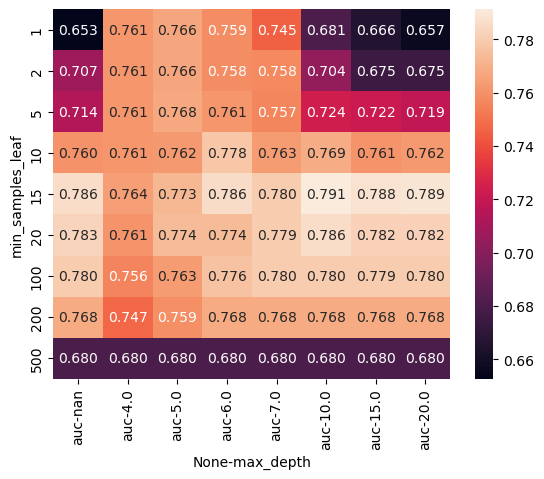

In [45]:
import seaborn as sns 

sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

In [46]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=15)

## 6.6 Ensembles and random forest

- Board of experts
- Ensembling models
- Random forest - ensembling decision trees
- Tuning random forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [51]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7744726453706618

In [52]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [53]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores.sort_values(by='auc', ascending=False)

,n_estimators,auc
19,200,0.819050
12,130,0.818253
13,140,0.818102
18,190,0.817981
15,160,0.817981
11,120,0.817939
16,170,0.817606
9,100,0.817599
10,110,0.817527
17,180,0.817463


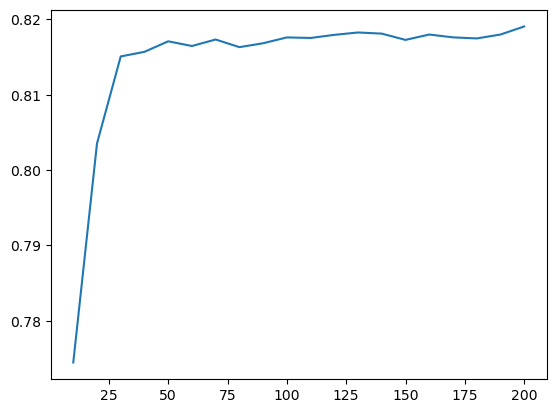

In [54]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [55]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [56]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'n_estimators', 'auc'])
df_scores.sort_values(by='auc', ascending=False)

,max_depth,n_estimators,auc
35,10,160,0.825243
39,10,200,0.824923
37,10,180,0.824801
36,10,170,0.824632
38,10,190,0.824535
32,10,130,0.824517
34,10,150,0.824166
33,10,140,0.824129
31,10,120,0.823227
30,10,110,0.822646


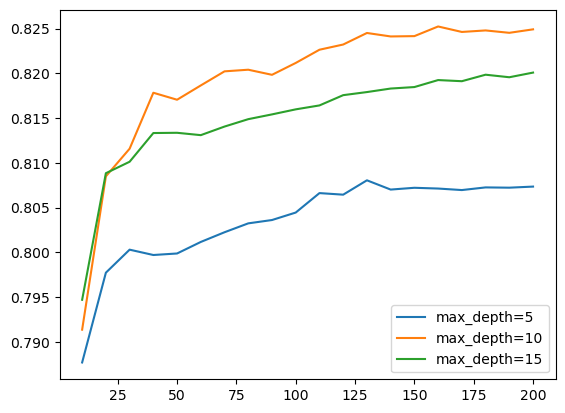

In [57]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%s' % d)

plt.legend()

In [58]:
max_depth = 10

In [59]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, 
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [60]:
df_scores = pd.DataFrame(scores, columns=['min_samples_leaf', 'n_estimators', 'auc'])
df_scores.sort_values(by='auc', ascending=False)

,min_samples_leaf,n_estimators,auc
58,5,190,0.825952
35,3,160,0.825655
59,5,200,0.825383
52,5,130,0.825286
37,3,180,0.825268
...,...,...,...
86,50,70,0.804712
87,50,80,0.804410
82,50,30,0.803562
80,50,10,0.798891


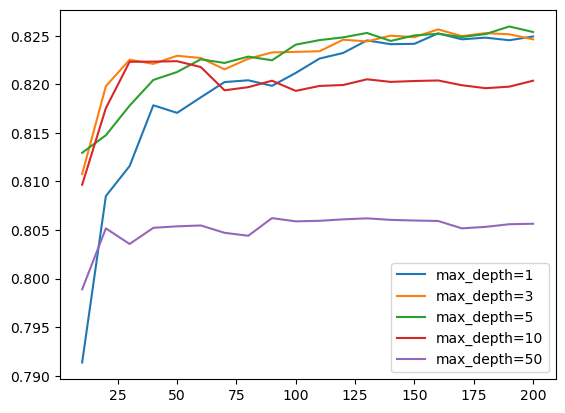

In [61]:
for s in [1, 3, 5, 10, 50]:
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%s' % s)

plt.legend()

In [62]:
min_samples_leaf = 5

In [63]:
rf = RandomForestClassifier(n_estimators=n, 
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1,
                           n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=1)

In [64]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8253826499721489

## 6.7 Gradient Boosting and XGBoost

- Gradient boosting vs random forest
- instaling XGBoost
- Training the first model
- Performance monitoring
- Parsing XGBoost's monitoring output

In [67]:
import xgboost as xgb

In [68]:
features = dv.get_feature_names_out()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(features))
dval = xgb.DMatrix(X_val, label=y_val, feature_names=list(features))

In [69]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [70]:
y_pred = model.predict(dval)

In [71]:
roc_auc_score(y_val, y_pred)

0.8065256351262986

In [72]:
watchlist = [(dtrain, 'train'), (dval, 'dval')]

In [73]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, 
                  dtrain,
                  evals=watchlist,
                  verbose_eval=5,
                  num_boost_round=200)

In [74]:
s = output.stdout
print(s)

[0]	train-auc:0.86730	dval-auc:0.77938
[5]	train-auc:0.93086	dval-auc:0.80858
[10]	train-auc:0.95447	dval-auc:0.80851
[15]	train-auc:0.96554	dval-auc:0.81334
[20]	train-auc:0.97464	dval-auc:0.81729
[25]	train-auc:0.97953	dval-auc:0.81686
[30]	train-auc:0.98579	dval-auc:0.81543
[35]	train-auc:0.99011	dval-auc:0.81206
[40]	train-auc:0.99421	dval-auc:0.80922
[45]	train-auc:0.99548	dval-auc:0.80842
[50]	train-auc:0.99653	dval-auc:0.80918
[55]	train-auc:0.99765	dval-auc:0.81114
[60]	train-auc:0.99817	dval-auc:0.81172
[65]	train-auc:0.99887	dval-auc:0.80798
[70]	train-auc:0.99934	dval-auc:0.80870
[75]	train-auc:0.99965	dval-auc:0.80555
[80]	train-auc:0.99979	dval-auc:0.80549
[85]	train-auc:0.99988	dval-auc:0.80374
[90]	train-auc:0.99993	dval-auc:0.80409
[95]	train-auc:0.99996	dval-auc:0.80548
[100]	train-auc:0.99998	dval-auc:0.80509
[105]	train-auc:0.99999	dval-auc:0.80629
[110]	train-auc:1.00000	dval-auc:0.80637
[115]	train-auc:1.00000	dval-auc:0.80494
[120]	train-auc:1.00000	dval-auc:0.805

In [75]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns) 

    return df_results

In [76]:
df_score = parse_xgb_output(output)

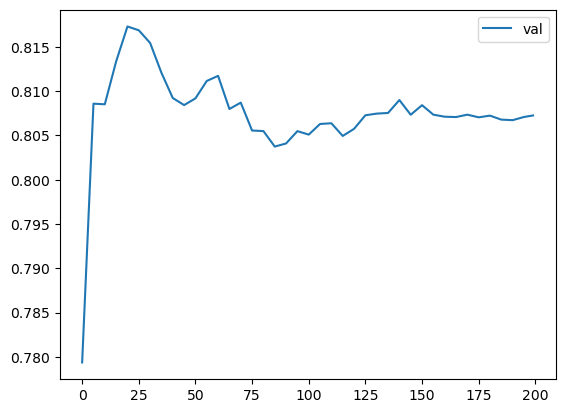

In [77]:
# plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
# plt.ylim(0, 1.1)
plt.legend()

## 6.8 XGBoost parameter tuning

Tuning the following parameters:
- `eta`
- `max_depth`
- `min_child_weight`

In [80]:
scores = {}

In [81]:
%%capture output

xgb_params = {
    'eta': 0.1, # (0.1, 0.05, 0.01)
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, 
                  dtrain,
                  evals=watchlist,
                  verbose_eval=5,
                  num_boost_round=200)

In [82]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.1'

In [83]:
scores.keys()

dict_keys(['eta=0.1'])

In [84]:
etas = ['eta=0.05', 'eta=0.1', 'eta=0.01']

for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)

plt.legend()

KeyError: 'eta=0.05'

In [ ]:
scores = {}

In [ ]:
%%capture output

xgb_params = {
    'eta': 0.1, #best eta that got from above plot 
    'max_depth': 6, #(3, 4, 6)
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, 
                  dtrain,
                  evals=watchlist,
                  verbose_eval=5,
                  num_boost_round=200)

In [ ]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

In [ ]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

plt.ylim(0.8, 0.84)
plt.legend()

In [ ]:
scores = {}

In [ ]:
%%capture output

xgb_params = {
    'eta': 0.1, #best eta that got from above plot 
    'max_depth': 3, #best max_depth
    'min_child_weight': 30, #(1, 10, 30)

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, 
                  dtrain,
                  evals=watchlist,
                  verbose_eval=5,
                  num_boost_round=200)

In [ ]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key

In [ ]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

plt.ylim(0.82, 0.84)
plt.legend()

In [85]:
xgb_params = {
    'eta': 0.1, #best eta that got from above plot 
    'max_depth': 3, #best max_depth
    'min_child_weight': 30, #best min_child_weight

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, 
                  dtrain,
                  num_boost_round=175)

## 6.9 Selecting the final model

- Choosing between xgboost, random forest, and decision tree
- Training the final model
- Saving the model

In [88]:
dt = DecisionTreeClassifier(max_depth=15, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, min_samples_leaf=15)

In [90]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7848290184301664

In [92]:
rf = RandomForestClassifier(n_estimators=200, 
                            max_depth=10,
                            min_samples_leaf=5,
                            random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=200,
                       random_state=1)

In [93]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8253826499721489

In [96]:
xgb_params = {
    'eta': 0.1, #best eta that got from above plot 
    'max_depth': 3, #best max_depth
    'min_child_weight': 30, #best min_child_weight

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, 
                  dtrain,
                  num_boost_round=175)

In [98]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

0.836632074786273

In [100]:
y_pred[:10]

array([0.05526957, 0.04993999, 0.12071707, 0.25079337, 0.06758471,
       0.0659973 , 0.03473382, 0.7859068 , 0.22597916, 0.01231974],
      dtype=float32)

In [126]:
df_full_train = df_full_train.reset_index(drop=True)

In [128]:
y_full_train = (df_full_train.status == 'default').astype(int).values

In [130]:
del df_full_train['status']

In [132]:
dicts_full_train = df_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.fillna(0).to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [134]:
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train,
                   feature_names=list(dv.get_feature_names_out()))

dtest = xgb.DMatrix(X_test, feature_names=list(dv.get_feature_names_out()))

In [138]:
xgb_params = {
    'eta': 0.1, #best eta that got from above plot 
    'max_depth': 3, #best max_depth
    'min_child_weight': 1, #best min_child_weight

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, 
                  dfulltrain,
                  num_boost_round=175)

In [140]:
y_pred = model.predict(dtest)
y_pred[:10]

array([0.2960169 , 0.23100702, 0.07417598, 0.27287325, 0.35843655,
       0.24473044, 0.00899626, 0.02323965, 0.24221162, 0.23622705],
      dtype=float32)

In [142]:
roc_auc_score(y_test, y_pred)

0.8310260984311617